# Экспоненциальный рост
**Цель:** Исследовать решение уравнения du/dt = au.

## Инициализация проекта и загрузка пакетов

In [2]:
using Pkg
Pkg.activate("../project")
using DrWatson
@quickactivate("project")
using DifferentialEquations
using Plots
default(fmt = :png)
using DataFrames
using JLD2

script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

  Activating new project at `~/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab01/project/notebooks/project`
  Activating project at `~/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab01/project`


"/home/ekpestova/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab01/project/data/"

## Определение модели
Уравнение экспоненциального роста:
du/dt = au, u(0) = u~0

In [3]:
function exponential_growth!(du, u, p, t)
    α = p
    du[1] = α * u[1]
end

exponential_growth! (generic function with 1 method)

## Первый запуск с параметрами по умолчанию
Зададим начальные параметры:

In [4]:
u0 = [1.0] # начальная популяция
α = 0.3 # скорость роста
tspan = (0.0, 10.0) # временной интервал
prob = ODEProblem(exponential_growth!, u0, tspan, α)
sol = solve(prob, Tsit5(), saveat=0.1)

retcode: Success
Interpolation: 1st order linear
t: 101-element Vector{Float64}:
  0.0
  0.1
  0.2
  0.3
  0.4
  0.5
  0.6
  0.7
  0.8
  0.9
  1.0
  1.1
  1.2
  ⋮
  8.9
  9.0
  9.1
  9.2
  9.3
  9.4
  9.5
  9.6
  9.7
  9.8
  9.9
 10.0
u: 101-element Vector{Vector{Float64}}:
 [1.0]
 [1.030454533950446]
 [1.061836555152965]
 [1.0941743028794024]
 [1.1274968605386604]
 [1.1618342327450657]
 [1.1972173476990728]
 [1.2336780571872645]
 [1.2712491879500911]
 [1.309964607386476]
 [1.3498590188274047]
 [1.390968273354931]
 [1.433329396499294]
 ⋮
 [14.439892233113852]
 [14.879627505085558]
 [15.332755966562287]
 [15.799688704213493]
 [16.280848967036345]
 [16.77667216635576]
 [17.28760587582435]
 [17.814109831422613]
 [18.3566559314586]
 [18.91572823656825]
 [19.49182296971528]
 [20.085448516190937]

## Визуализация результатов
Построим график решения:

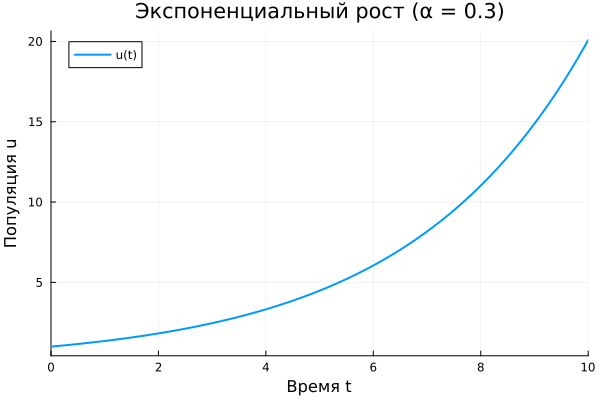

In [5]:
plot(sol, label="u(t)", xlabel="Время t", ylabel="Популяция u",
     title="Экспоненциальный рост (α = $α)", lw=2, legend=:topleft)

Сохраним график в папку plots

In [6]:
savefig(plotsdir(script_name, "exponential_growth_α=$α.png"))

"/home/ekpestova/work/study/2026-1/2026-1--study--simulation-modeling/labs/lab01/project/plots/exponential_growth_α=0.3.png"

## Анализ результатов
Создадим таблицу с данными:

In [7]:
df = DataFrame(t=sol.t, u=first.(sol.u))
println("Первые 5 строк результатов:")
println(first(df, 5))

Первые 5 строк результатов:
5×2 DataFrame
 Row │ t        u       
     │ Float64  Float64 
─────┼──────────────────
   1 │     0.0  1.0
   2 │     0.1  1.03045
   3 │     0.2  1.06184
   4 │     0.3  1.09417
   5 │     0.4  1.1275


Вычислим удвоение популяции:

In [8]:
u_final = last(sol.u)[1]
doubling_time = log(2) / α
println("\nАналитическое время удвоения: ", round(doubling_time; digits=2))


Аналитическое время удвоения: 2.31


## Сохранение всех результатов

In [9]:
@save datadir(script_name, "all_results.jld2") df